In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

plt.style.use('default')


runs =

[df1, df2, df3, ...]

(each CSV = one dataframe)

run_names =

["run1.csv", "run2.csv", ...]

In [2]:
train_path = "../data/train"

runs = []
run_names = []

for file in os.listdir(train_path):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(train_path, file))
        df['run_id'] = file
        runs.append(df)
        run_names.append(file)

print(f"Loaded {len(runs)} runs")

Loaded 28 runs


In [3]:
df_all = pd.concat(runs, ignore_index=True)

print(df_all.shape)
df_all.head()

(189444, 19)


,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,T712,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702,run_id
0,1.0,1.0,357.647,68.216,58.930,64.381,64.076,59.227,54.534,52.440,52.268,52.579,0.059,0.397,-0.121,1.707,299.372,3.902,series_012.csv
1,1.0,1.0,357.808,68.279,58.951,64.402,64.076,59.248,54.534,52.440,52.310,52.537,0.061,0.390,-0.183,1.733,299.659,3.643,series_012.csv
2,1.0,1.0,357.808,68.237,58.951,64.381,64.033,59.227,54.492,52.440,52.310,52.558,0.064,0.385,-0.217,1.750,299.668,3.902,series_012.csv
3,1.0,1.0,357.808,68.237,58.951,64.381,64.055,59.248,54.492,52.461,52.289,52.537,0.004,0.380,-0.231,1.629,299.776,3.556,series_012.csv
4,1.0,1.0,357.877,68.216,58.930,64.338,64.055,59.248,54.492,52.440,52.310,52.537,0.004,0.376,-0.223,1.631,299.785,3.556,series_012.csv


In [4]:
df_all.info()
df_all.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 189444 entries, 0 to 189443
Data columns (total 19 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   LS701   189444 non-null  float64
 1   LS702   189444 non-null  float64
 2   T701    189444 non-null  float64
 3   T702    189444 non-null  float64
 4   T703    189444 non-null  float64
 5   T704    189444 non-null  float64
 6   T706    189444 non-null  float64
 7   T708    189444 non-null  float64
 8   T709    189444 non-null  float64
 9   T711    189444 non-null  float64
 10  T712    189444 non-null  float64
 11  T705    189444 non-null  float64
 12  FT703   189444 non-null  float64
 13  FT704   189444 non-null  float64
 14  PDI701  189444 non-null  float64
 15  PDI702  189444 non-null  float64
 16  PY23    189444 non-null  float64
 17  FYI702  189444 non-null  float64
 18  run_id  189444 non-null  str    
dtypes: float64(18), str(1)
memory usage: 27.5 MB


,count,mean,std,min,25%,50%,75%,max
LS701,189444.0,0.999208,0.028128,0.000000,1.000000,1.000000,1.000000,1.000
LS702,189444.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000
T701,189444.0,370.400444,58.370389,72.709000,306.502000,380.495000,423.753000,499.351
T702,189444.0,89.273647,13.908859,59.085000,76.327000,89.292000,97.006000,119.391
T703,189444.0,80.089245,13.461201,50.713000,70.500000,80.655975,87.099000,108.622
T704,189444.0,84.448638,13.964958,30.800000,71.801000,84.233180,92.017000,127.000
T706,189444.0,84.505022,13.943849,33.200000,71.900000,84.291000,92.027000,128.800
T708,189444.0,79.784680,13.867808,35.800000,70.000000,79.346620,87.089056,127.300
T709,189444.0,76.211787,14.512207,46.798000,67.518000,75.707000,82.703000,107.596
T711,189444.0,70.394713,14.341429,44.441000,63.290000,69.695000,75.923000,107.331


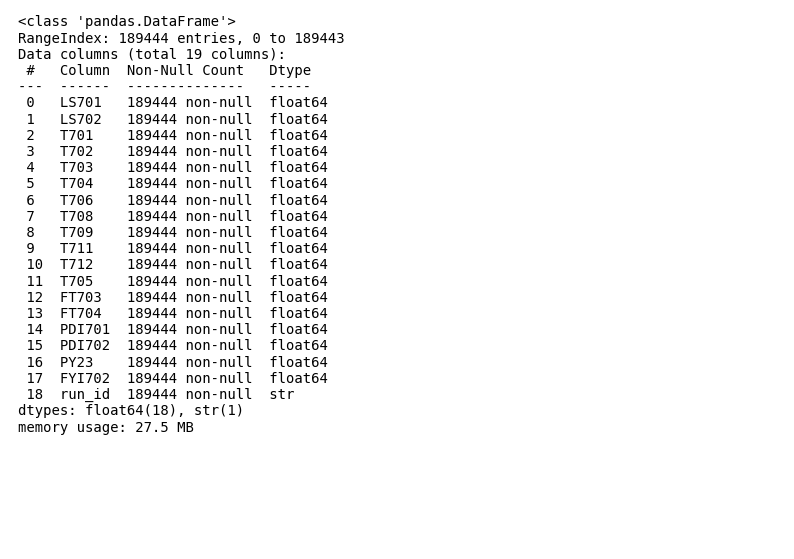

Saved at: ../plots/df_all_info.png


In [5]:
import matplotlib.pyplot as plt
from io import StringIO

# capture df_all.info() output
buffer = StringIO()
df_all.info(buf=buffer)
info_text = buffer.getvalue()

# create figure
plt.figure(figsize=(10, 7))
plt.text(
    0.01, 0.99,
    info_text,
    fontfamily="monospace",
    fontsize=10,
    va='top'
)

plt.axis('off')

# save image (use your project-safe path)
save_path = "../plots/df_all_info.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)

plt.show()

print("Saved at:", save_path)

Why?

Because:

Sensors → usually numeric 
Algorithms (PCA, KMeans, CNN features, etc.) → need numbers 
Text columns → useless for these steps 

In [6]:
sensor_cols = df_all.select_dtypes(include=[np.number]).columns
sensor_cols = [col for col in sensor_cols if col not in ['run_id', 'label']]

print(sensor_cols)

['LS701', 'LS702', 'T701', 'T702', 'T703', 'T704', 'T706', 'T708', 'T709', 'T711', 'T712', 'T705', 'FT703', 'FT704', 'PDI701', 'PDI702', 'PY23', 'FYI702']


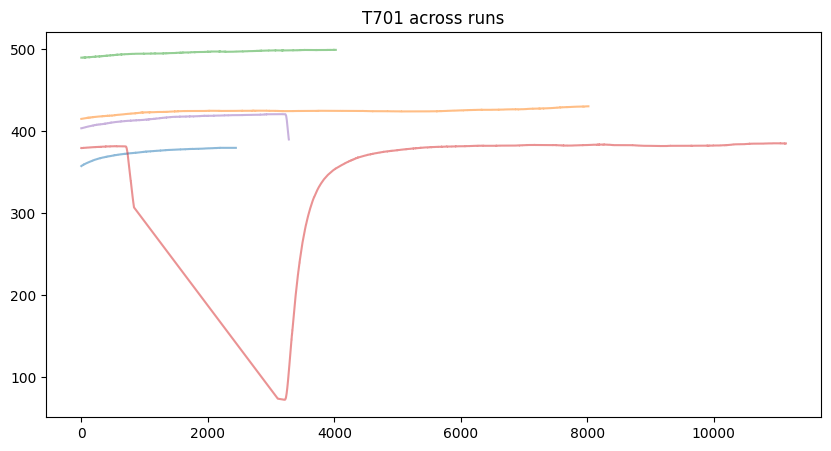

In [7]:
sample_runs = df_all['run_id'].unique()[:5]

plt.figure(figsize=(10,5))

for run in sample_runs:
    temp = df_all[df_all['run_id'] == run]
    plt.plot(temp[sensor_cols[2]].values, alpha=0.5)

plt.title(f"{sensor_cols[2]} across runs")
plt.show()

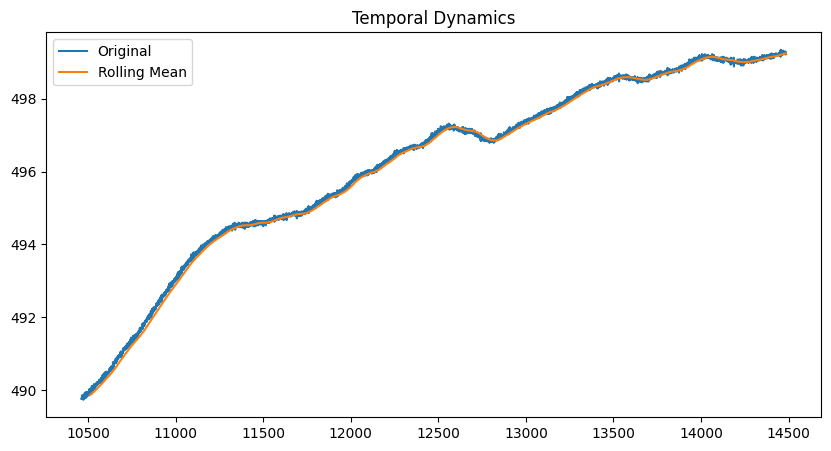

In [8]:
sample_run = df_all[df_all['run_id'] == sample_runs[2]].copy()

sample_run['rolling_mean'] = sample_run[sensor_cols[2]].rolling(50).mean()
sample_run['rolling_std'] = sample_run[sensor_cols[2]].rolling(50).std()

plt.figure(figsize=(10,5))
plt.plot(sample_run[sensor_cols[2]], label='Original')
plt.plot(sample_run['rolling_mean'], label='Rolling Mean')
plt.legend()
plt.title("Temporal Dynamics")
plt.show()

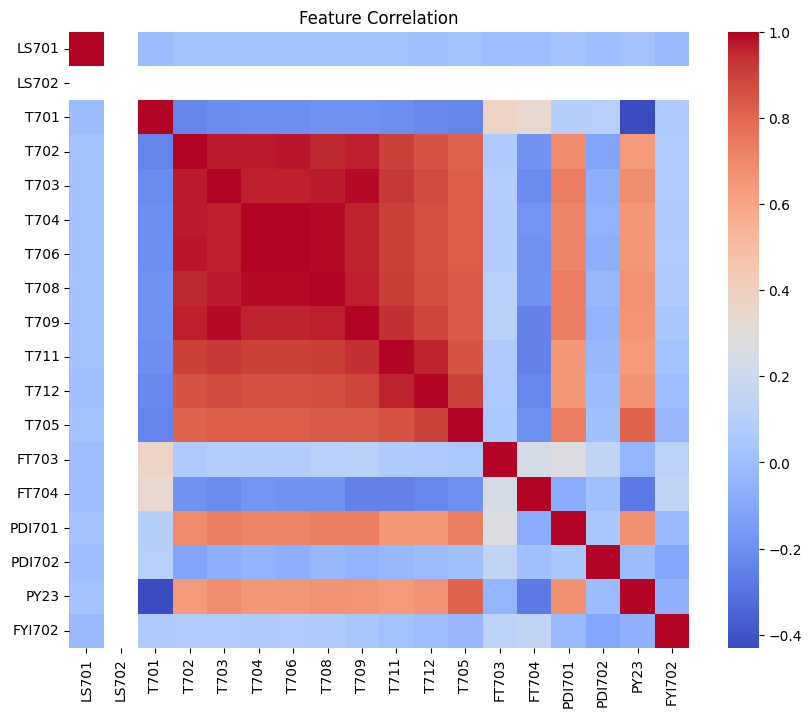

In [9]:
corr = df_all[sensor_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

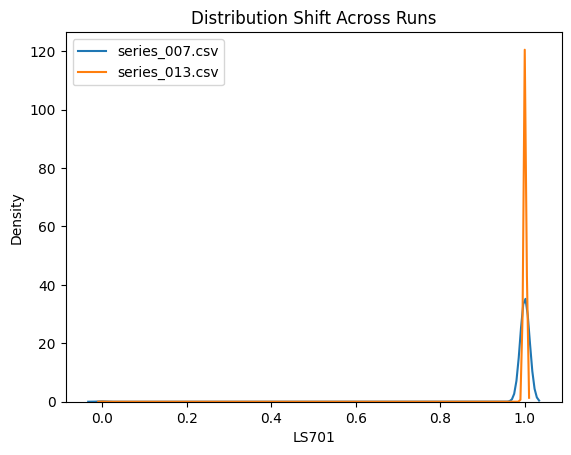

In [36]:
run1 = df_all[df_all['run_id'] == sample_runs[2]]
run2 = df_all[df_all['run_id'] == sample_runs[3]]

sns.kdeplot(run1[sensor_cols[0]], label=sample_runs[2])
sns.kdeplot(run2[sensor_cols[0]], label=sample_runs[3])

plt.legend()
plt.title("Distribution Shift Across Runs")
plt.show()

PHASE 1: Data Quality & Sanity Check
Goal:

“Is my data trustworthy?”

What to do:
Missing values,
constant columns,
duplicates,
datatype check.

In [11]:
df_all.isnull().sum()

LS701     0
LS702     0
T701      0
T702      0
T703      0
T704      0
T706      0
T708      0
T709      0
T711      0
T712      0
T705      0
FT703     0
FT704     0
PDI701    0
PDI702    0
PY23      0
FYI702    0
run_id    0
dtype: int64

In [12]:

df_all.nunique()

LS701         2
LS702         1
T701      12446
T702       8761
T703       7696
T704       9146
T706       8911
T708       9181
T709       8069
T711       6562
T712       6140
T705       5282
FT703      6797
FT704      8456
PDI701     6345
PDI702     9697
PY23      12761
FYI702     3528
run_id       28
dtype: int64

LS702 → 1 unique value

 This is a constant sensor

always = 1
zero variance
no information

Decision: DROP this feature later

In [13]:
df_all.describe()

,LS701,LS702,T701,T702,T703,T704,T706,T708,T709,T711,T712,T705,FT703,FT704,PDI701,PDI702,PY23,FYI702
count,189444.000000,189444.0,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000,189444.000000
mean,0.999208,1.0,370.400444,89.273647,80.089245,84.448638,84.505022,79.784680,76.211787,70.394713,69.082895,66.849883,0.171244,0.360430,0.580121,2.019515,586.002178,4.332111
std,0.028128,0.0,58.370389,13.908859,13.461201,13.964958,13.943849,13.867808,14.512207,14.341429,13.463271,10.249268,0.154988,0.203541,0.348927,0.530566,193.515105,1.402520
min,0.000000,1.0,72.709000,59.085000,50.713000,30.800000,33.200000,35.800000,46.798000,44.441000,44.291000,37.599000,0.000000,0.000000,-0.510094,-1.569000,198.277000,0.000000
25%,1.000000,1.0,306.502000,76.327000,70.500000,71.801000,71.900000,70.000000,67.518000,63.290000,63.245000,63.230000,0.080000,0.215000,0.461000,1.839503,496.447000,3.643000
50%,1.000000,1.0,380.495000,89.292000,80.655975,84.233180,84.291000,79.346620,75.707000,69.695000,67.689000,67.458000,0.147000,0.358000,0.665000,1.998000,598.044500,3.902000
75%,1.000000,1.0,423.753000,97.006000,87.099000,92.017000,92.027000,87.089056,82.703000,75.923000,73.686000,71.924000,0.249000,0.468000,0.793222,2.143000,699.166000,4.878000
max,1.000000,1.0,499.351000,119.391000,108.622000,127.000000,128.800000,127.300000,107.596000,107.331000,107.268000,105.137000,3.139000,4.000000,1.436000,7.361000,979.048000,8.000000


## 📊 Data Quality Observations

- No missing values in training data, but validation data contains missing values → indicates real-world noise and must be handled during preprocessing.

- Sensor LS702 is constant (only one unique value) → provides no useful information and can be removed.

- Sensor LS701 is binary (0/1) → likely represents system state and should be retained.

- Sensor PY23 shows very high variance (std ≈ 193) → highly dynamic and potentially very important for anomaly detection.

- Sensor T701 also shows high variability → strong contributing feature.

- Temperature sensors (T702–T712) show moderate variance → stable but informative.

- Flow and pressure sensors (FT703, FT704, PDI701, PDI702) show low variance → may act as stabilizing features.

- Some sensors (e.g., FT703, PDI702) exhibit extreme max values → possible spikes or anomalies in the data.

- Several sensors show slight skewness → distributions are not perfectly normal.

PHASE-2 : Sensor Distribution Shift Analysis


In [14]:
sensor_cols = [col for col in df_all.columns if col != 'run_id']

In [15]:
runs = df_all['run_id'].unique()

In [16]:
from scipy.stats import wasserstein_distance

results = []

for sensor in sensor_cols:
    for i in range(len(runs)):
        for j in range(i+1, len(runs)):
            
            run1 = df_all[df_all['run_id'] == runs[i]][sensor]
            run2 = df_all[df_all['run_id'] == runs[j]][sensor]
            
            dist = wasserstein_distance(run1, run2)
            
            results.append({
                'sensor': sensor,
                'run_1': runs[i],
                'run_2': runs[j],
                'distance': dist
            })

df_dist = pd.DataFrame(results)

In [17]:
sensor_shift = (
    df_dist.groupby('sensor')['distance']
    .mean()
    .sort_values(ascending=False)
)

print(sensor_shift.head(19))

sensor
PY23      208.513640
T701       63.226079
T709       15.862446
T702       15.279584
T706       15.121336
T704       15.084901
T708       15.031964
T703       14.846477
T711       14.657479
T712       13.026553
T705       10.707303
FYI702      1.762288
PDI701      0.420972
PDI702      0.377449
FT704       0.215706
FT703       0.141826
LS701       0.001541
LS702       0.000000
Name: distance, dtype: float64


/var/folders/l2/crklz3gd0yvcxq04hlhk4rcr0000gn/T/ipykernel_27412/4221907129.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


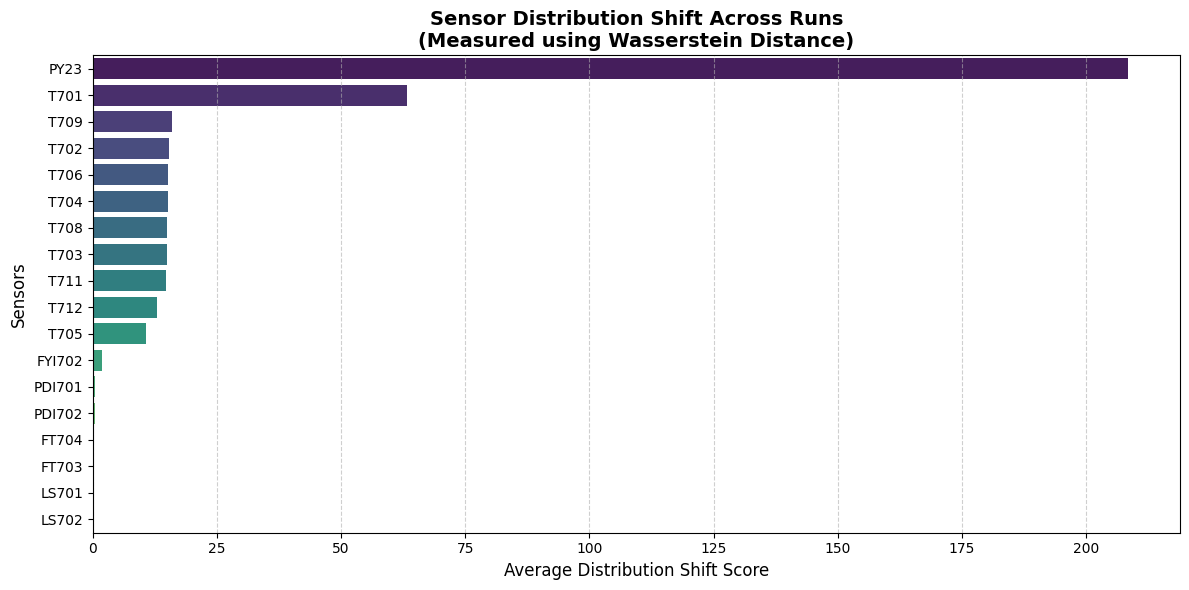

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    x=sensor_shift.values,
    y=sensor_shift.index,
    palette="viridis"
)

plt.title(
    "Sensor Distribution Shift Across Runs\n"
    "(Measured using Wasserstein Distance)",
    fontsize=14,
    fontweight='bold'
)

plt.xlabel("Average Distribution Shift Score", fontsize=12)
plt.ylabel("Sensors", fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Sensor Distribution Shift Analysis

This plot shows the average distribution shift of each sensor across different runs, 
measured using the Wasserstein distance.

Higher values indicate that the sensor's behavior varies significantly between runs,
suggesting sensitivity to changing system conditions.

Lower values indicate stable sensors with consistent behavior across runs.

PHASE-3 : What does each sensor’s data look like?

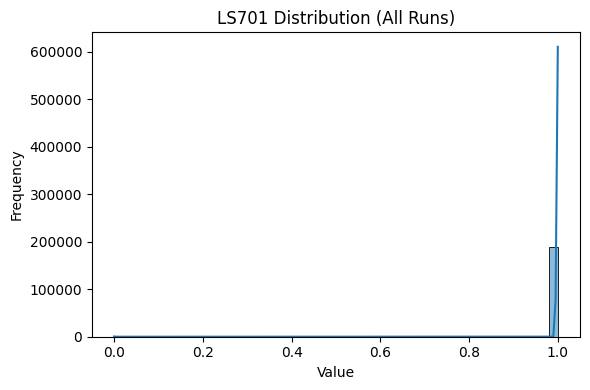

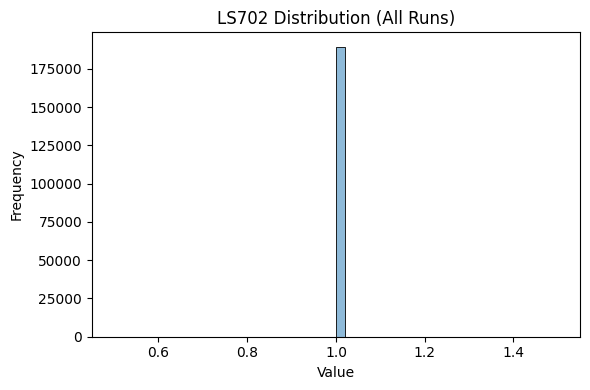

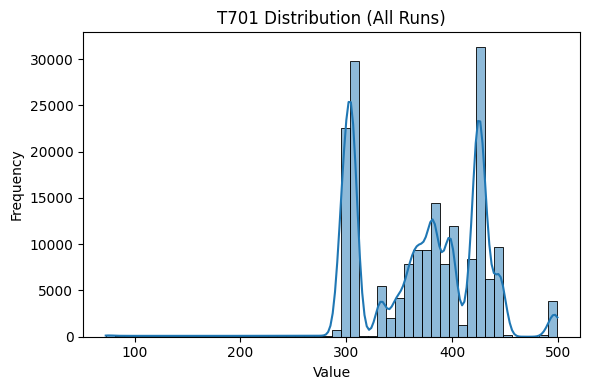

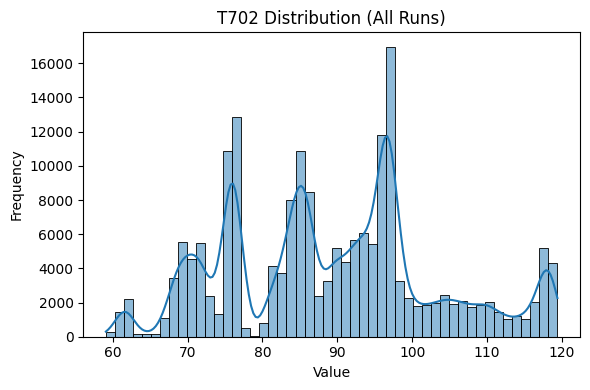

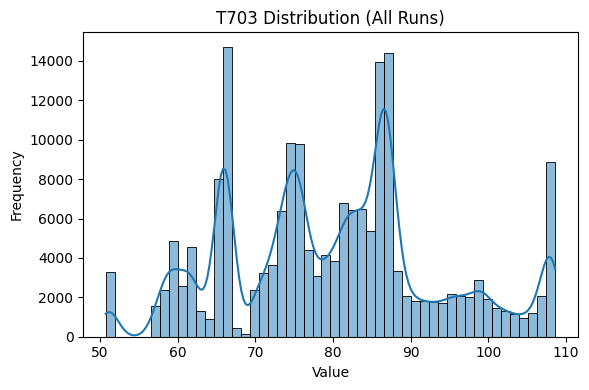

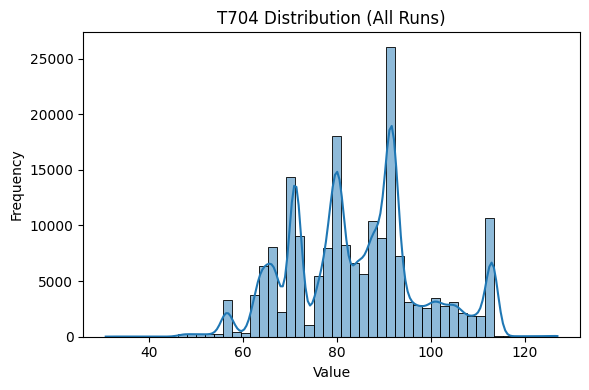

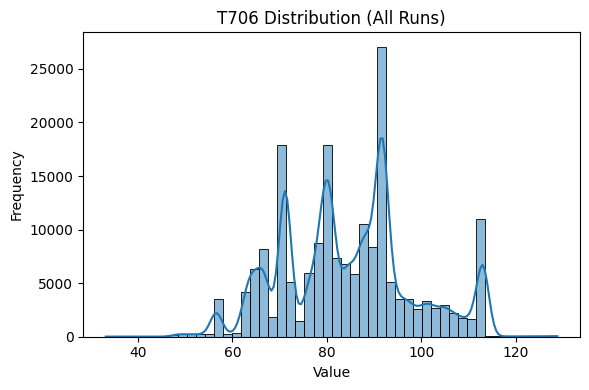

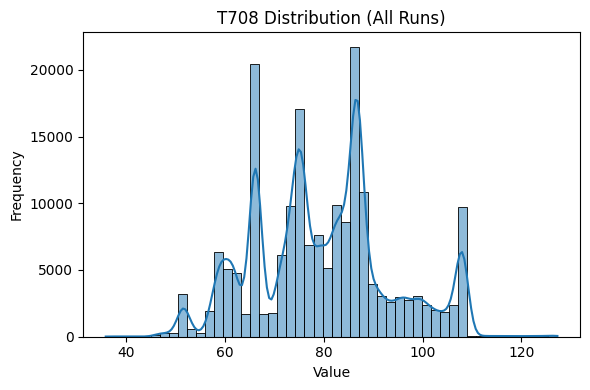

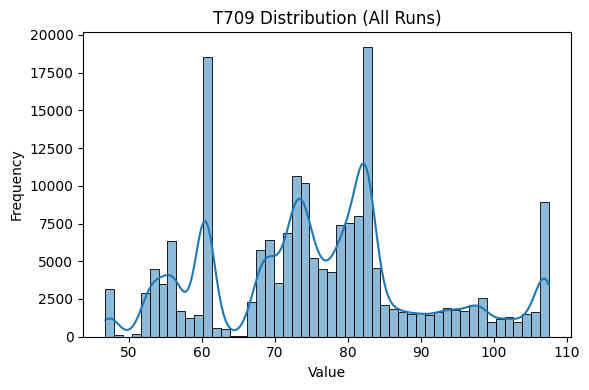

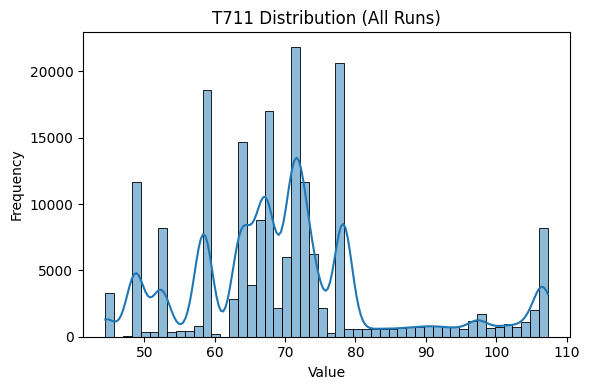

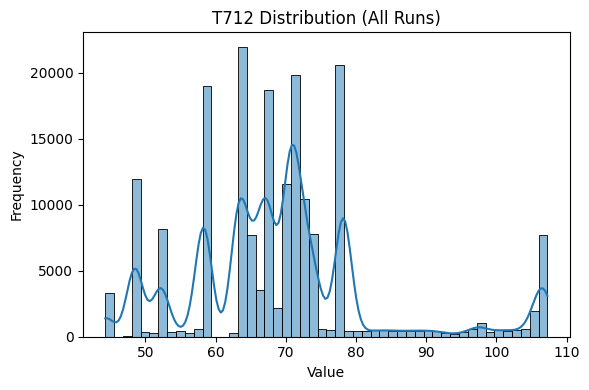

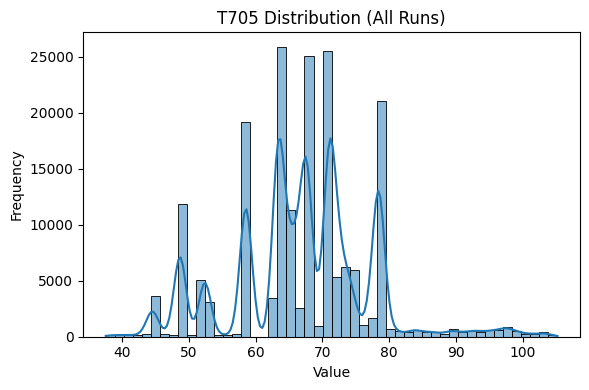

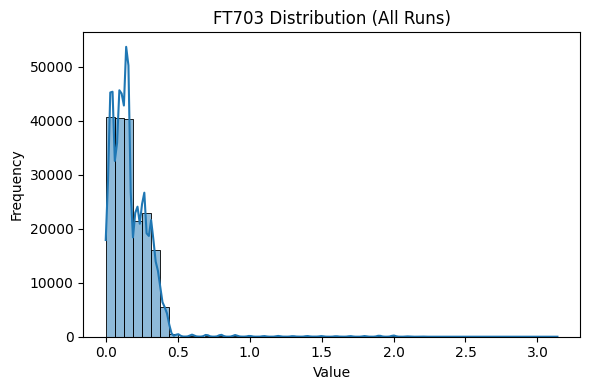

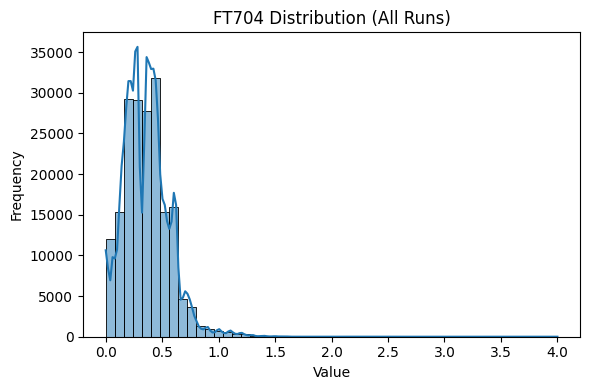

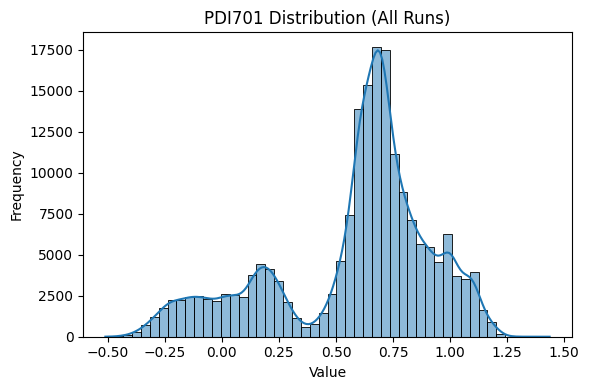

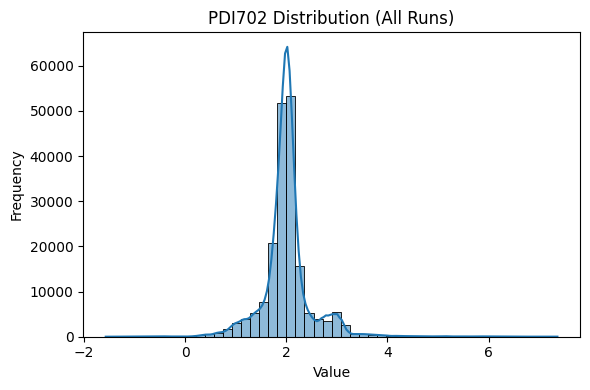

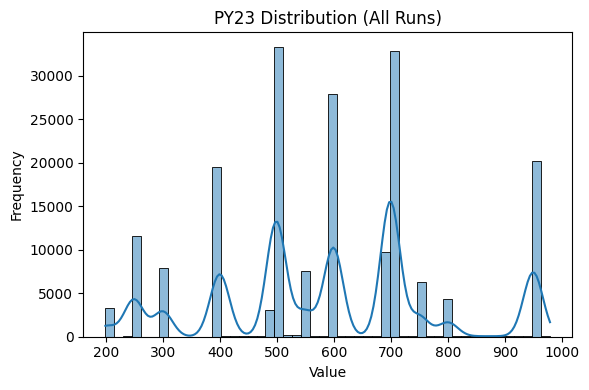

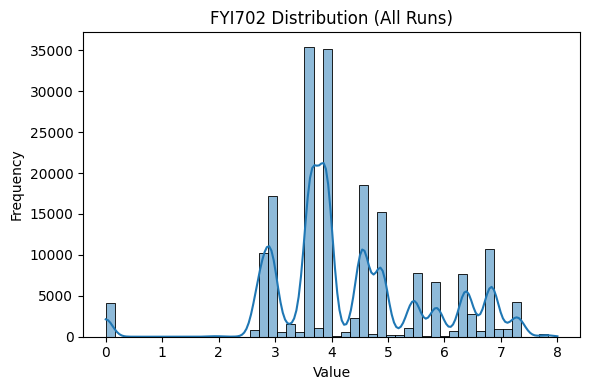

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

for sensor in sensor_cols:
    plt.figure(figsize=(6,4))
    
    sns.histplot(df_all[sensor], bins=50, kde=True)
    
    plt.title(f"{sensor} Distribution (All Runs)")
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()

### Sensor Categorization based on Distribution Behavior

Sensor distributions were analyzed using KDE and summarized using statistical features.

- **Variability (Standard Deviation):** measures how much the sensor values fluctuate  
- **Complexity (Number of Peaks):** indicates how many distinct patterns or modes exist  
- **Tail Behavior (Kurtosis/Skew):** captures extreme values or unusual deviations  

Using these features, sensors were categorized as:

- **Stable:** low variability, consistent behavior  
- **Highly Dynamic:** multiple peaks indicating different operating states  
- **Spike Sensitive:** high kurtosis or skew showing extreme values  
- **Normal:** moderate and consistent behavior  

This categorization helps in understanding sensor roles and guides preprocessing and model selection.

/var/folders/l2/crklz3gd0yvcxq04hlhk4rcr0000gn/T/ipykernel_27412/1345292747.py:21: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skew": skew(data),
/var/folders/l2/crklz3gd0yvcxq04hlhk4rcr0000gn/T/ipykernel_27412/1345292747.py:22: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "kurtosis": kurtosis(data)


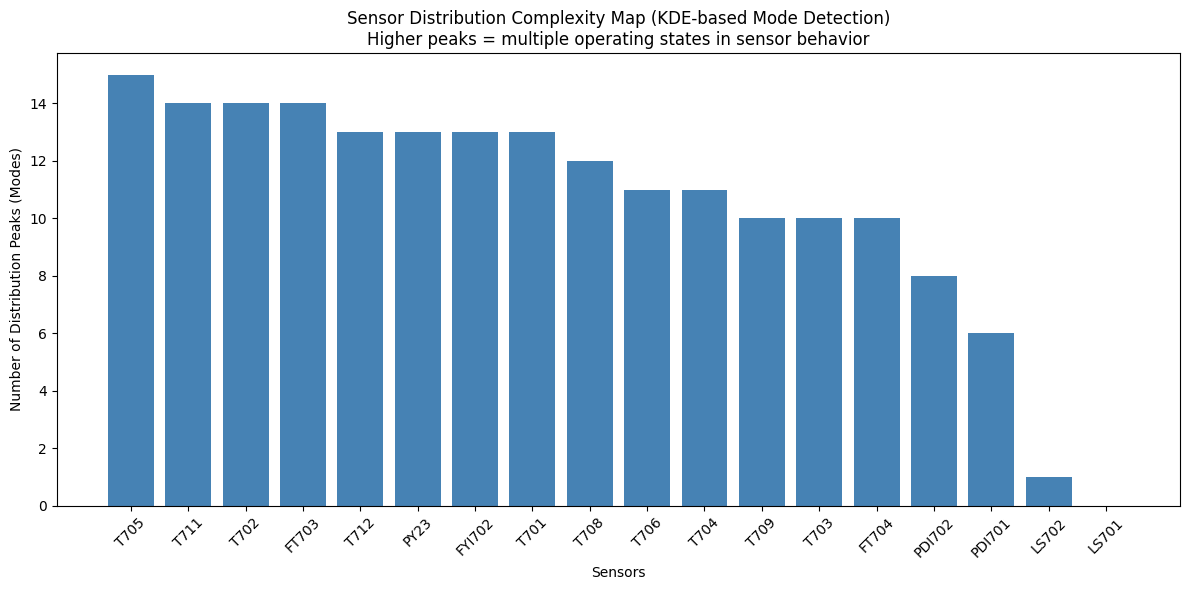

    num_peaks        mean         std       skew     kurtosis  sensor
11         15   66.849883   10.249241   0.189233     0.971100    T705
9          14   70.394713   14.341391   0.835165     0.745006    T711
3          14   89.273647   13.908822   0.232244    -0.527223    T702
12         14    0.171244    0.154987   5.015175    49.071586   FT703
10         13   69.082895   13.463236   0.967161     1.492783    T712
16         13  586.002178  193.514594   0.101066    -0.428582    PY23
17         13    4.332111    1.402517   0.046066     0.771979  FYI702
2          13  370.400444   58.370235  -0.566411     1.100733    T701
7          12   79.784680   13.867771   0.235087    -0.301338    T708
6          11   84.505022   13.943812   0.201599    -0.331786    T706
5          11   84.448638   13.964921   0.194878    -0.306857    T704
8          10   76.211787   14.512168   0.275747    -0.341046    T709
4          10   80.089245   13.461166   0.211471    -0.434301    T703
13         10    0.3

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import skew, kurtosis

# -----------------------------
# 1. FUNCTION: Analyze sensor distribution
# -----------------------------
def analyze_sensor(data, bins=50):
    data = data.dropna()

    hist, bin_edges = np.histogram(data, bins=bins, density=True)

    peaks, _ = find_peaks(hist)

    return {
        "num_peaks": len(peaks),
        "mean": np.mean(data),
        "std": np.std(data),
        "skew": skew(data),
        "kurtosis": kurtosis(data)
    }


# -----------------------------
# 2. RUN ANALYSIS FOR ALL SENSORS
# -----------------------------
sensor_results = []

for sensor in sensor_cols:
    stats = analyze_sensor(df_all[sensor])
    stats["sensor"] = sensor
    sensor_results.append(stats)

df_summary = pd.DataFrame(sensor_results)


# -----------------------------
# 3. SORT BY COMPLEXITY (important for insight)
# -----------------------------
df_summary = df_summary.sort_values("num_peaks", ascending=False)


# -----------------------------
# 4. VISUALIZATION: SENSOR COMPLEXITY MAP
# -----------------------------
plt.figure(figsize=(12,6))

plt.bar(df_summary["sensor"], df_summary["num_peaks"], color="steelblue")

plt.xticks(rotation=45)
plt.ylabel("Number of Distribution Peaks (Modes)")
plt.xlabel("Sensors")

plt.title(
    "Sensor Distribution Complexity Map (KDE-based Mode Detection)\n"
    "Higher peaks = multiple operating states in sensor behavior"
)

plt.tight_layout()
plt.show()


# -----------------------------
# 5. OPTIONAL: PRINT TABLE FOR REPORT
# -----------------------------
print(df_summary)

In [21]:
# Compute thresholds
std_low = df_summary['std'].quantile(0.1)
peaks_high = df_summary['num_peaks'].quantile(0.8)
kurt_high = df_summary['kurtosis'].quantile(0.8)

def categorize_sensor(row):
    if row['std'] < std_low:
        return "Stable"

    elif row['num_peaks'] > peaks_high:
        return "Highly Dynamic"

    elif row['kurtosis'] > kurt_high:
        return "Spike Sensitive"

    else:
        return "Normal"

df_summary['category'] = df_summary.apply(categorize_sensor, axis=1)

In [22]:
print(df_summary["category"].value_counts())

category
Normal             10
Highly Dynamic      4
Spike Sensitive     2
Stable              2
Name: count, dtype: int64



📊 Sensor Groups based on KDE-derived statistics:

🔹 Highly Dynamic:
T705, T711, T702, FT703

🔹 Normal:
T712, PY23, FYI702, T701, T708, T706, T704, T709, T703, PDI701

🔹 Spike Sensitive:
FT704, PDI702

🔹 Stable:
LS702, LS701



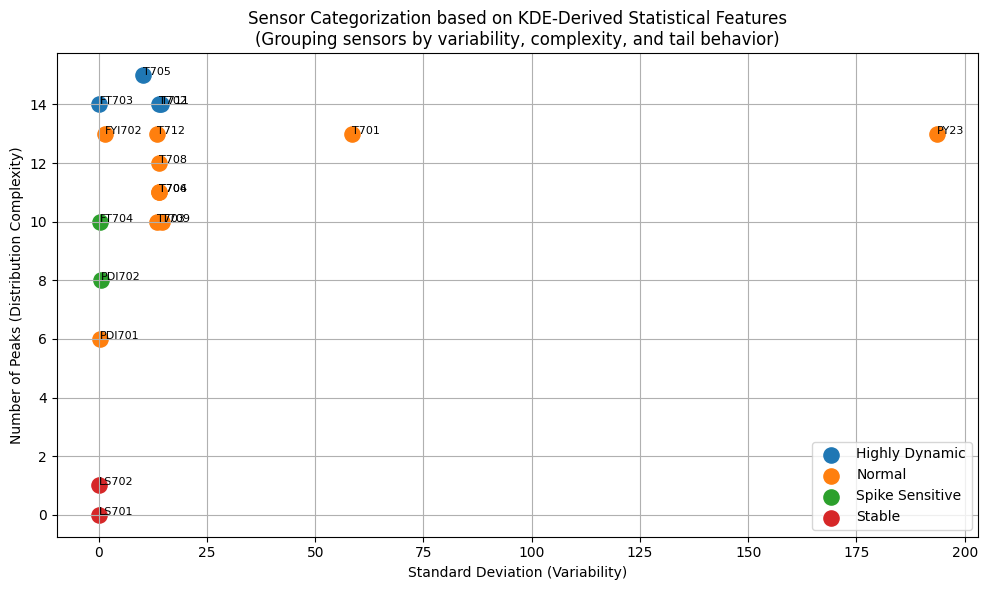

In [23]:
import matplotlib.pyplot as plt

# -----------------------------
# GROUP SENSORS
# -----------------------------
groups = df_summary.groupby("category")["sensor"].apply(list)

print("\n📊 Sensor Groups based on KDE-derived statistics:\n")
for category, sensors in groups.items():
    print(f"🔹 {category}:")
    print(", ".join(sensors))
    print()


# -----------------------------
# PLOT (PRESENTATION READY)
# -----------------------------
plt.figure(figsize=(10,6))

# scatter plot: std vs num_peaks
for category in df_summary["category"].unique():
    subset = df_summary[df_summary["category"] == category]
    
    plt.scatter(
        subset["std"],
        subset["num_peaks"],
        label=category,
        s=120
    )

# annotate sensors
for _, row in df_summary.iterrows():
    plt.text(row["std"], row["num_peaks"], row["sensor"], fontsize=8)

plt.xlabel("Standard Deviation (Variability)")
plt.ylabel("Number of Peaks (Distribution Complexity)")

plt.title(
    "Sensor Categorization based on KDE-Derived Statistical Features\n"
    "(Grouping sensors by variability, complexity, and tail behavior)"
)

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
groups = df_summary.groupby("category")["sensor"].apply(list)

groups

category
Highly Dynamic                             [T705, T711, T702, FT703]
Normal             [T712, PY23, FYI702, T701, T708, T706, T704, T...
Spike Sensitive                                      [FT704, PDI702]
Stable                                                [LS702, LS701]
Name: sensor, dtype: object

In [25]:
df_all.columns
df_summary.columns

Index(['num_peaks', 'mean', 'std', 'skew', 'kurtosis', 'sensor', 'category'], dtype='str')

In [26]:
df_final = None

In [27]:
df_shift = sensor_shift.reset_index()
df_shift.columns = ["sensor", "avg_distribution_shift"]

In [28]:
df_nunique = (
    df_all.drop(columns=["run_id"])
    .nunique()
    .reset_index()
)

df_nunique.columns = ["sensor", "nunique"]

In [29]:
df_final = df_summary.merge(df_shift, on="sensor", how="left")
df_final = df_final.merge(df_nunique, on="sensor", how="left")

In [30]:
df_nunique = df_all.drop(columns=["run_id"]).nunique().reset_index()
df_nunique.columns = ["sensor", "nunique"]

In [31]:
df_final = df_summary.merge(df_shift, on="sensor", how="left")
df_final = df_final.merge(df_nunique, on="sensor", how="left")

In [32]:
print(df_final.columns)

Index(['num_peaks', 'mean', 'std', 'skew', 'kurtosis', 'sensor', 'category',
       'avg_distribution_shift', 'nunique'],
      dtype='str')


In [ ]:
print(df_final.columns)

Index(['sensor', 'mean', 'std', 'skew', 'kurtosis', 'num_peaks', 'nunique',
       'category', 'avg_distribution_shift'],
      dtype='str')


In [34]:
df_sensor_features = df_final.copy()

In [ ]:
df_sensor_features = df_final.copy()

# -----------------------------
# THRESHOLDS
# -----------------------------
shift_high = df_sensor_features["avg_distribution_shift"].quantile(0.75)
shift_low = df_sensor_features["avg_distribution_shift"].quantile(0.25)

std_low = df_sensor_features["std"].quantile(0.2)
peak_high = df_sensor_features["num_peaks"].quantile(0.8)
kurt_high = df_sensor_features["kurtosis"].quantile(0.8)
nunique_low = df_sensor_features["nunique"].quantile(0.2)

# -----------------------------
# CATEGORIZATION LOGIC
# -----------------------------
def categorize_sensor(row):

    shift = row["avg_distribution_shift"]
    std = row["std"]
    peaks = row["num_peaks"]
    kurt = row["kurtosis"]
    nunique = row["nunique"]

    # stable or binary-like sensors
    if std < std_low or nunique <= 2:
        return "Stable / Binary Sensor"

    # unstable across runs
    if shift > shift_high:
        if kurt > kurt_high:
            return "Critical Unstable (Anomalous)"
        return "Unstable Sensor"

    # high internal complexity
    if peaks > peak_high:
        return "Highly Dynamic Sensor"

    # low information content
    if nunique < nunique_low:
        return "Low Information Sensor"

    return "Reliable Sensor"


df_sensor_features["final_category"] = df_sensor_features.apply(categorize_sensor, axis=1)

# -----------------------------
# GROUP OUTPUT
# -----------------------------
groups = df_sensor_features.groupby("final_category")["sensor"].apply(list)

print("\n📊 Sensor Categories:\n")
for k, v in groups.items():
    print(f"{k}:")
    print(v)
    print()


📊 Sensor Categories:

Highly Dynamic Sensor:
['PDI701', 'PDI702', 'FYI702']

Low Information Sensor:
['T705']

Reliable Sensor:
['T703', 'T704', 'T708', 'T711', 'T712']

Stable / Binary Sensor:
['LS701', 'LS702', 'FT703', 'FT704']

Unstable Sensor:
['T701', 'T702', 'T706', 'T709', 'PY23']



In [ ]:
import pandas as pd

summary_table = df_sensor_features.groupby("final_category").agg(
    Sensor_Count=("sensor", "count"),
    Avg_STD=("std", "mean"),
    Avg_Shift=("avg_distribution_shift", "mean"),
    Avg_Peaks=("num_peaks", "mean"),
    Avg_Unique=("nunique", "mean")
).reset_index()

summary_table

,final_category,Sensor_Count,Avg_STD,Avg_Shift,Avg_Peaks,Avg_Unique
0,Highly Dynamic Sensor,3,0.760671,0.853570,47721.0,6523.333333
1,Low Information Sensor,1,10.249268,10.707303,28574.0,5282.000000
2,Reliable Sensor,5,13.819733,14.529475,30608.0,7745.000000
3,Stable / Binary Sensor,4,0.096664,0.089768,14866.0,3814.000000
4,Unstable Sensor,5,58.850082,63.600617,32018.0,10189.600000


<Figure size 1000x500 with 0 Axes>

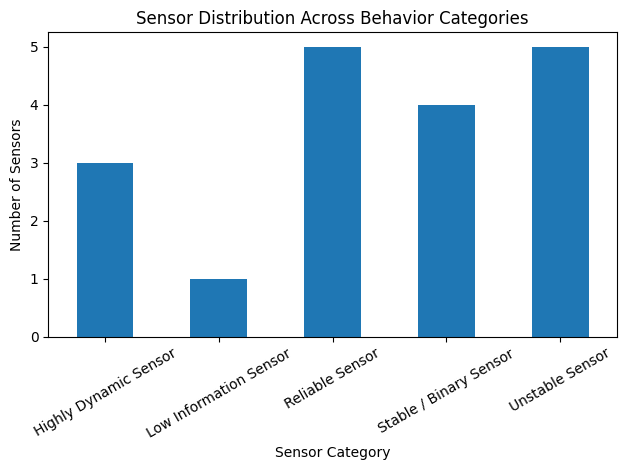

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

summary_table.plot(
    x="final_category",
    y="Sensor_Count",
    kind="bar",
    legend=False
)

plt.title("Sensor Distribution Across Behavior Categories")
plt.xlabel("Sensor Category")
plt.ylabel("Number of Sensors")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
display_table = summary_table.set_index("final_category")

display_table

,Sensor_Count,Avg_STD,Avg_Shift,Avg_Peaks,Avg_Unique
final_category,,,,,
Highly Dynamic Sensor,3,0.760671,0.853570,47721.0,6523.333333
Low Information Sensor,1,10.249268,10.707303,28574.0,5282.000000
Reliable Sensor,5,13.819733,14.529475,30608.0,7745.000000
Stable / Binary Sensor,4,0.096664,0.089768,14866.0,3814.000000
Unstable Sensor,5,58.850082,63.600617,32018.0,10189.600000


In [ ]:
group_stats = df_sensor_features.groupby("final_category")[[
    "std",
    "avg_distribution_shift",
    "num_peaks",
    "nunique"
]].mean()

In [ ]:
group_norm = (group_stats - group_stats.min()) / (group_stats.max() - group_stats.min())
group_norm

,std,avg_distribution_shift,num_peaks,nunique
final_category,,,,
Highly Dynamic Sensor,0.011302,0.012026,1.000000,0.424953
Low Information Sensor,0.172800,0.167177,0.417227,0.230253
Reliable Sensor,0.233571,0.227358,0.479136,0.616569
Stable / Binary Sensor,0.000000,0.000000,0.000000,0.000000
Unstable Sensor,1.000000,1.000000,0.522051,1.000000


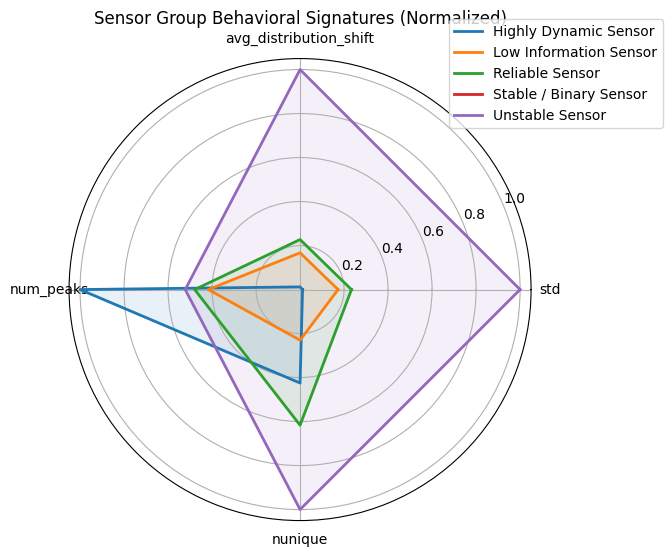

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = group_norm.columns
num_vars = len(labels)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True))

for idx, row in group_norm.iterrows():
    values = row.tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2, label=idx)
    ax.fill(angles, values, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Sensor Group Behavioral Signatures (Normalized)")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

In [ ]:
features = ["std", "avg_distribution_shift", "num_peaks", "nunique"]

group_stats = df_sensor_features.groupby("final_category")[features].mean()

In [ ]:
group_norm = (group_stats - group_stats.min()) / (group_stats.max() - group_stats.min())

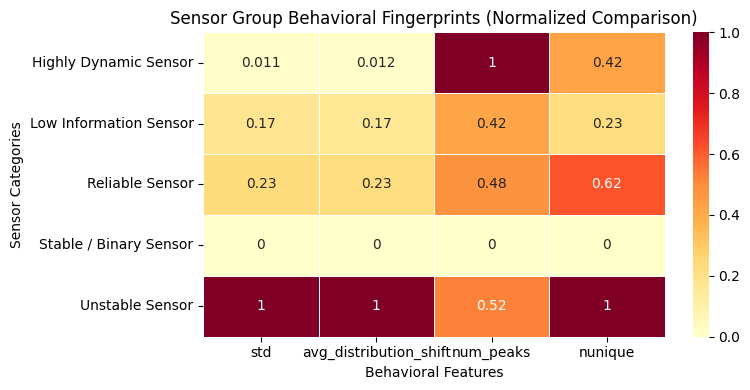

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

sns.heatmap(
    group_norm,
    annot=True,
    cmap="YlOrRd",
    linewidths=0.5
)

plt.title("Sensor Group Behavioral Fingerprints (Normalized Comparison)")
plt.xlabel("Behavioral Features")
plt.ylabel("Sensor Categories")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# CONFIG
# -----------------------------
window = 100

sensor_cols = [col for col in df_all.columns if col not in ["run_id"]]

rolling_features = []

# -----------------------------
# ROLLING FEATURE EXTRACTION
# -----------------------------
for sensor in sensor_cols:
    
    series = df_all[sensor]

    # rolling stats
    roll_mean = series.rolling(window=window, min_periods=1).mean()
    roll_std = series.rolling(window=window, min_periods=1).std()

    # features
    rolling_mean_std = roll_mean.std()
    rolling_std_mean = roll_std.mean()

    # trend strength
    x = np.arange(len(series))

    if len(series.dropna()) > 10:
        trend_strength = np.polyfit(
            x,
            series.ffill(),
            1
        )[0]
    else:
        trend_strength = 0

    # IMPORTANT: inside loop
    rolling_features.append({
        "sensor": sensor,
        "rolling_mean_std": rolling_mean_std,
        "rolling_std_mean": rolling_std_mean,
        "trend_strength": trend_strength
    })

# -----------------------------
# CREATE FINAL TABLE
# -----------------------------
df_rolling = pd.DataFrame(rolling_features)

print(df_rolling.head())

  sensor  rolling_mean_std  rolling_std_mean  trend_strength
0  LS701          0.003209          0.007147   -2.631074e-09
1  LS702          0.000000          0.000000   -4.537377e-20
2   T701         58.234844          0.535469   -2.996893e-04
3   T702         13.878592          0.164200    8.987108e-05
4   T703         13.430637          0.137530    8.361146e-05


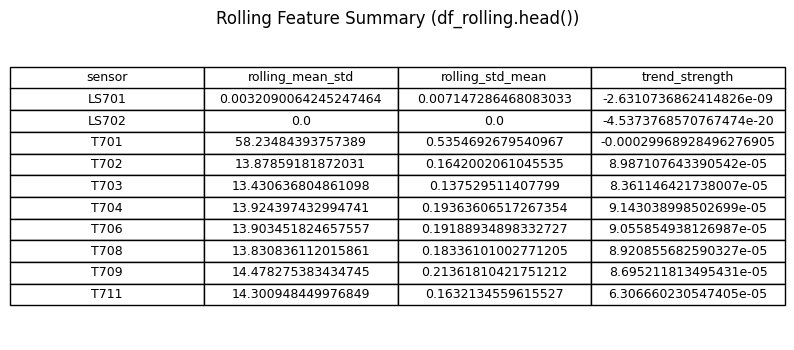

In [ ]:
import matplotlib.pyplot as plt

# take head
df_sample = df_rolling.head(10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")

table = ax.table(
    cellText=df_sample.values,
    colLabels=df_sample.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

plt.title("Rolling Feature Summary (df_rolling.head())", fontsize=12)


plt.show()

In [ ]:
df_final = df_summary.merge(df_shift, on="sensor", how="left")
df_final = df_final.merge(df_rolling, on="sensor", how="left")

df_final.head()

,sensor,mean,std,skew,kurtosis,num_peaks,nunique,category,avg_distribution_shift,rolling_mean_std,rolling_std_mean,trend_strength
0,LS701,0.999208,0.028128,-35.495926,1257.960792,1,2,Stable,0.001541,0.003209,0.007147,-2.631074e-09
1,LS702,1.000000,0.000000,NaN,NaN,0,1,Stable,0.000000,0.000000,0.000000,-4.537377e-20
2,T701,370.400444,58.370389,-0.566411,1.100733,37337,12446,Normal,63.226079,58.234844,0.535469,-2.996893e-04
3,T702,89.273647,13.908859,0.232244,-0.527223,37455,8761,Normal,15.279584,13.878592,0.164200,8.987108e-05
4,T703,80.089245,13.461201,0.211471,-0.434301,26129,7696,Normal,14.846477,13.430637,0.137530,8.361146e-05


In [ ]:
def score_sensor(row):
    
    score = 0

    # stability (good if low shift)
    if row["avg_distribution_shift"] < df_final["avg_distribution_shift"].quantile(0.3):
        score += 2

    # noise (bad if high std)
    if row["rolling_std_mean"] > df_final["rolling_std_mean"].quantile(0.7):
        score -= 2

    # stability of trend (good if stable)
    if row["rolling_mean_std"] < df_final["rolling_mean_std"].quantile(0.3):
        score += 2

    # drift penalty
    if abs(row["trend_strength"]) > df_final["trend_strength"].abs().quantile(0.7):
        score -= 1

    return score


df_final["sensor_score"] = df_final.apply(score_sensor, axis=1)

In [ ]:
def categorize(row):
    
    if row["sensor_score"] >= 3:
        return "Highly Useful Sensor"

    elif row["sensor_score"] >= 1:
        return "Useful Sensor"

    elif row["sensor_score"] >= -1:
        return "Moderate Sensor"

    else:
        return "Unstable / Low Utility Sensor"


df_final["final_category"] = df_final.apply(categorize, axis=1)

In [ ]:
df_final.groupby("final_category")["sensor"].apply(list)

final_category
Highly Useful Sensor             [LS701, LS702, FT703, FT704, PDI701, PDI702]
Moderate Sensor                          [T702, T703, T708, T711, T712, T705]
Unstable / Low Utility Sensor          [T701, T704, T706, T709, PY23, FYI702]
Name: sensor, dtype: object

In [ ]:
df_compare = df_final[[
    "sensor",
    "category",          # KDE-based
    "final_category"     # rolling-based
]]

In [ ]:
pd.crosstab(
    df_compare["category"],
    df_compare["final_category"]
)

final_category,Highly Useful Sensor,Moderate Sensor,Unstable / Low Utility Sensor
category,,,
Highly Dynamic,3,0,1
Normal,0,6,5
Spike Sensitive,1,0,0
Stable,2,0,0


In [ ]:
crosstab = pd.crosstab(
    df_compare["category"],
    df_compare["final_category"]
)

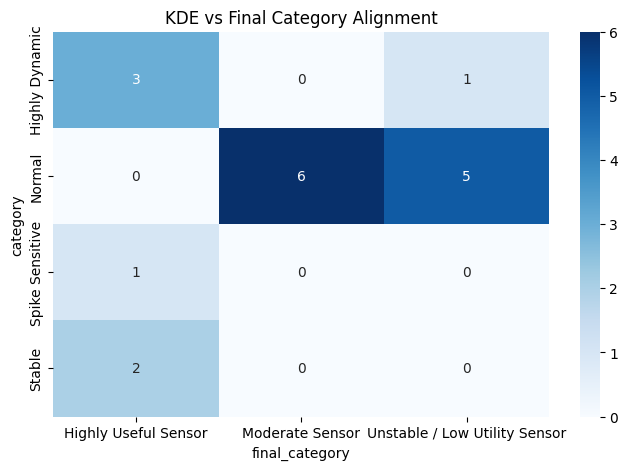

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.heatmap(crosstab, annot=True, fmt="d", cmap="Blues")
plt.title("KDE vs Final Category Alignment")
plt.show()

In [ ]:
import os

save_path = "../data/processed"

os.makedirs(save_path, exist_ok=True)

df_final.to_csv(f"{save_path}/df_sensor_features.csv", index=False)

In [ ]:
df_summary.to_csv(f"{save_path}/df_kde_summary.csv", index=False)

In [ ]:
df_summary.groupby("category")["sensor"].apply(list).to_csv(
    f"{save_path}/kde_groups.csv"
)

In [ ]:
df_final.groupby("final_category")["sensor"].apply(list).to_csv(
    f"{save_path}/final_groups.csv"
)

In [ ]:
import pandas as pd

crosstab = pd.crosstab(
    df_final["category"],
    df_final["final_category"]
)

crosstab.to_csv(f"{save_path}/kde_vs_final_crosstab.csv")

In [ ]:
df_rolling.to_csv(f"{save_path}/rolling_features.csv", index=False)

In [ ]:
print(df_final.columns)

Index(['sensor', 'mean', 'std', 'skew', 'kurtosis', 'num_peaks', 'nunique',
       'category', 'avg_distribution_shift', 'rolling_mean_std',
       'rolling_std_mean', 'trend_strength', 'sensor_score', 'final_category',
       'score_norm', 'final_interpretation'],
      dtype='str')
